# Payoff structures — straddle, strangle, iron condor, iron fly, naked buy/sell

Research notebook for the Convex Hedge payoff engine.

**What this notebook establishes**

1. The pricing model, verified against a 517,672-row oracle rather than trusted.
2. A payoff function that works for *any* combination of legs, so strategies are presets rather than special cases.
3. Max profit, max loss and breakevens — including the case where they are unbounded.
4. Payoff charts on the expiry line and on a target date.

**Scope**: straddle, strangle, naked long/short call, naked long/short put. Iron condor, iron fly and
credit spread use the identical machinery and are added by listing different legs.

**Sources for every claim below** — issues [#2](https://github.com/lalitkarthik/convex-hedge-payoff/issues/2)
and [#6](https://github.com/lalitkarthik/convex-hedge-payoff/issues/6), and `docs/data-quality.md`.

## 1. Setup

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE = ROOT / "Data" / "sample" / "chain_2026-01-27.parquet"

# NIFTY lot size, confirmed 65 on 19 Aug 2026 (map #1). Margin mechanics stay open in issue #4.
LOT_SIZE = 65

TRADING_DAYS_PER_YEAR = 252  # established in issue #2

## 2. The data

One trading day of the NIFTY chain — 27 January 2026, expiry 10 February 2026.

Two things about this file that are not obvious and cost real time to discover (see `docs/data-quality.md`):

- `ts` is **UTC**. The source `options.parquet` is IST stamped at the bar *close* (`:59`); `greeks.parquet`
  is UTC stamped at the bar *open* (`:00`). Joining them naively returns zero rows and no warning.
- `dte_days` is a **trading-time clock**. One session consumes exactly 1.0; overnight and weekends
  consume nothing. Theta accrues only while the market is open.

We use the **close** of each 1-minute bar throughout, which is what `last` already holds — verified as
identical to `options.Close` on 100% of rows.

In [2]:
chain = pd.read_parquet(SAMPLE)
chain["ist"] = chain.ts + pd.Timedelta(hours=5, minutes=30)

print(f"rows      {len(chain):,}")
print(f"session   {chain.ist.min():%H:%M} -> {chain.ist.max():%H:%M} IST on {chain.ist.dt.date.iloc[0]}")
print(f"strikes   {chain.strike.nunique()}  ({chain.strike.min():.0f} - {chain.strike.max():.0f})")
print(f"dte_days  {chain.dte_days.max():.4f} at open -> {chain.dte_days.min():.4f} at close")
chain.head(3)

rows      23,581
session   09:15 -> 15:30 IST on 2026-01-27
strikes   94  (23300 - 27950)
dte_days  11.0000 at open -> 10.0000 at close


,ts,strike,option_type,Open,High,Low,Close,Volume,OpenInterest,Ticker,...,delta,gamma,theta,vega,rho,vanna,volga,charm,spot,ist
0,2026-01-27 03:45:00,23350.0,PE,19.15,19.35,19.0,19.0,1170,0,NIFTY10FEB2623350PE.NFO,...,-0.040644,0.000077,-4.294955,4.589929,-0.454762,-0.006859,0.628664,0.006734,25113.05,2026-01-27 09:15:00
1,2026-01-27 03:45:00,23400.0,PE,22.05,22.25,20.5,20.5,1755,20280,NIFTY10FEB2623400PE.NFO,...,-0.043716,0.000082,-4.531928,4.868650,-0.489155,-0.007188,0.645895,0.007020,25113.05,2026-01-27 09:15:00
2,2026-01-27 03:45:00,23450.0,PE,23.75,23.75,21.4,21.4,1820,4355,NIFTY10FEB2623450PE.NFO,...,-0.045958,0.000087,-4.658043,5.068765,-0.514183,-0.007489,0.663581,0.007221,25113.05,2026-01-27 09:15:00


### Pick a moment to analyse

Midday, so the chain is liquid and we are clear of the open and close auctions.

In [3]:
SNAPSHOT_TIME = pd.Timestamp("2026-01-27 12:00:00")

snap = chain[chain.ist == SNAPSHOT_TIME].copy()

SPOT     = float(snap.spot.iloc[0])
FORWARD  = float(snap.forward.iloc[0])
DISCOUNT = float(snap.discount.iloc[0])
DTE      = float(snap.dte_days.iloc[0])
T        = DTE / TRADING_DAYS_PER_YEAR

print(f"spot      {SPOT:,.2f}")
print(f"forward   {FORWARD:,.2f}   (basis {FORWARD - SPOT:+.2f} points)")
print(f"discount  {DISCOUNT:.6f}")
print(f"dte_days  {DTE:.4f}   ->  T = {DTE:.4f}/252 = {T:.6f} years")
print(f"legs available: {len(snap)} across {snap.strike.nunique()} strikes")

spot      25,100.25
forward   25,219.12   (basis +118.87 points)
discount  0.993480
dte_days  10.5600   ->  T = 10.5600/252 = 0.041905 years
legs available: 58 across 49 strikes


## 3. The pricing model

**Black-76 on the forward**, not textbook Black-Scholes on the spot. Established in
[#2](https://github.com/lalitkarthik/convex-hedge-payoff/issues/2) by testing both against the oracle.

$$
d_1 = \frac{\ln(F/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}
\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

$$
\text{Call} = D\,\bigl[F\,N(d_1) - K\,N(d_2)\bigr]
\qquad
\text{Put} = D\,\bigl[K\,N(-d_2) - F\,N(-d_1)\bigr]
$$

Why the forward and not the spot: the forward already contains the dividends and the cost of carry, so
neither appears in the formula. One fewer thing to estimate, and one fewer thing to get wrong.

**Time is in trading days over 252.** Using calendar days over 365 puts delta out by a median of 0.025 —
small enough to look like a rounding bug, large enough to make every downstream number wrong.

In [4]:
def black76_price(F, K, T, sigma, D, is_call):
    '''Black-76 price of a European option on a forward.

    F, K, sigma may be arrays. At T <= 0 the option is worth its discounted intrinsic value.
    '''
    F, K, sigma = np.asarray(F, float), np.asarray(K, float), np.asarray(sigma, float)

    if T <= 0:
        intrinsic = np.maximum(F - K, 0.0) if is_call else np.maximum(K - F, 0.0)
        return D * intrinsic

    v = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / v
    d2 = d1 - v

    if is_call:
        return D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


def black76_greeks(F, K, T, sigma, D, is_call):
    '''Delta, gamma, vega, theta, rho in the oracle's conventions (issue #2).'''
    v = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / v
    d2 = d1 - v

    price = black76_price(F, K, T, sigma, D, is_call)
    r = -np.log(D) / T                      # continuous rate implied by the discount factor

    # theta is a one-trading-day finite difference, NOT the analytic formula (issue #2)
    T_next = max(T - 1 / TRADING_DAYS_PER_YEAR, 1e-12)
    D_next = np.exp(-r * T_next)
    theta = black76_price(F, K, T_next, sigma, D_next, is_call) - price

    return {
        "price": price,
        "delta": norm.cdf(d1) if is_call else norm.cdf(d1) - 1.0,   # undiscounted
        "gamma": norm.pdf(d1) / (F * v),                            # undiscounted
        "vega":  D * F * norm.pdf(d1) * np.sqrt(T) / 100,           # per vol point
        "theta": theta,                                             # per trading day
        "rho":  (D * K * T * norm.cdf(d2) if is_call
                 else -D * K * T * norm.cdf(-d2)) / 100,            # per 1% rate
    }

### Verify before trusting

This is the point of the whole exercise. We do not accept the formulas because they look right — we
grade them against 23,581 rows the vendor solved independently.

In [5]:
errors = {}
for name in ["delta", "gamma", "vega", "theta", "rho"]:
    errors[name] = []

for _, row in chain.sample(2000, random_state=0).iterrows():
    g = black76_greeks(
        row.forward, row.strike, row.dte_days / TRADING_DAYS_PER_YEAR,
        row.iv, row.discount, row.option_type == "CE",
    )
    for name in errors:
        errors[name].append(abs(g[name] - row[name]))

report = pd.DataFrame({
    "max abs error": {k: max(v) for k, v in errors.items()},
    "oracle median": {k: chain[k].abs().median() for k in errors},
})
print(report.to_string(float_format=lambda x: f"{x:.3e}"))
assert all(max(v) < 1e-6 for v in errors.values()), "model disagrees with the oracle"
print("\nAll five Greeks match the oracle. The model is correct.")

       max abs error  oracle median
delta      2.220e-16      2.522e-01
gamma      2.168e-19      3.551e-04
vega       8.882e-15      1.577e+01
theta      7.276e-12      1.271e+01
rho        3.553e-15      2.643e+00

All five Greeks match the oracle. The model is correct.


## 4. Legs and strategies

A **Leg** is one option contract. A **Strategy** is a list of legs and nothing more.

This is the design decision worth noticing: an iron condor is not a *type*, it is four legs. Every
formula below works on an arbitrary list, so adding a new strategy means listing different legs, not
writing new code.

Section 8 puts that to the test: the iron condor and the iron fly are four legs each and cost
zero lines of new code.

In [6]:
@dataclass(frozen=True)
class Leg:
    strike: float
    option_type: str      # "CE" or "PE"
    direction: int        # +1 bought, -1 sold
    entry_price: float
    iv: float
    quantity: int = 1

    @property
    def is_call(self):
        return self.option_type == "CE"

    def __repr__(self):
        side = "B" if self.direction > 0 else "S"
        return f"{side} {self.quantity}x {self.strike:.0f} {self.option_type} @ {self.entry_price:.2f}"


def leg_from_chain(strike, option_type, direction, quantity=1, snapshot=None):
    '''Build a Leg from the observed chain. Entry price is the 1-min bar close.'''
    snapshot = snap if snapshot is None else snapshot
    row = snapshot[(snapshot.strike == strike) & (snapshot.option_type == option_type)]
    if row.empty:
        raise KeyError(f"{strike:.0f} {option_type} not quoted at this minute")
    row = row.iloc[0]
    return Leg(strike, option_type, direction, float(row.last), float(row.iv), quantity)

### Choose the strikes

At-the-money is the strike nearest the **forward**, not the spot — the forward is what the pricing model
sees. Here they differ by ~120 points, which is more than two strike intervals.

In [7]:
quoted = snap.groupby("strike").option_type.nunique()
both_sides = set(quoted[quoted == 2].index)          # strikes with a live CE and PE

ATM = min(both_sides, key=lambda k: abs(k - FORWARD))
WING = 300
OTM_CALL = min((k for k in both_sides if k >= ATM + WING), default=None)
OTM_PUT  = max((k for k in both_sides if k <= ATM - WING), default=None)

# Wings for the four-legged structures. A condor wing is a single option, so it does not need
# the strike quoted on both sides - and at this minute nothing above 25,500 is. Restricting the
# wings to `both_sides` would leave the far call wing unbuildable.
ce_strikes = set(snap.loc[snap.option_type == "CE", "strike"])
pe_strikes = set(snap.loc[snap.option_type == "PE", "strike"])

NEAR, FAR = 300, 600
FLY_CALL    = min(k for k in ce_strikes if k >= ATM + NEAR)
FLY_PUT     = max(k for k in pe_strikes if k <= ATM - NEAR)
CONDOR_CALL = min(k for k in ce_strikes if k >= ATM + FAR)
CONDOR_PUT  = max(k for k in pe_strikes if k <= ATM - FAR)

print(f"forward        {FORWARD:,.2f}")
print(f"ATM strike     {ATM:,.0f}")
print(f"strangle wings {OTM_PUT:,.0f} PE / {OTM_CALL:,.0f} CE")
print(f"fly wings      {FLY_PUT:,.0f} PE / {FLY_CALL:,.0f} CE")
print(f"condor wings   {CONDOR_PUT:,.0f} PE / {CONDOR_CALL:,.0f} CE")

STRATEGIES = {
    "Long Straddle":   [leg_from_chain(ATM, "CE", +1), leg_from_chain(ATM, "PE", +1)],
    "Short Straddle":  [leg_from_chain(ATM, "CE", -1), leg_from_chain(ATM, "PE", -1)],
    "Long Strangle":   [leg_from_chain(OTM_CALL, "CE", +1), leg_from_chain(OTM_PUT, "PE", +1)],
    "Iron Fly":        [leg_from_chain(ATM, "CE", -1), leg_from_chain(ATM, "PE", -1),
                        leg_from_chain(FLY_CALL, "CE", +1), leg_from_chain(FLY_PUT, "PE", +1)],
    "Iron Condor":     [leg_from_chain(FLY_CALL, "CE", -1), leg_from_chain(FLY_PUT, "PE", -1),
                        leg_from_chain(CONDOR_CALL, "CE", +1), leg_from_chain(CONDOR_PUT, "PE", +1)],
    "Naked Long Call":  [leg_from_chain(ATM, "CE", +1)],
    "Naked Short Call": [leg_from_chain(ATM, "CE", -1)],
    "Naked Long Put":   [leg_from_chain(ATM, "PE", +1)],
    "Naked Short Put":  [leg_from_chain(ATM, "PE", -1)],
}

for name, legs in STRATEGIES.items():
    print(f"  {name:<18} {legs}")

forward        25,219.12
ATM strike     25,200
strangle wings 24,800 PE / 25,500 CE
fly wings      24,900 PE / 25,500 CE
condor wings   24,600 PE / 25,800 CE
  Long Straddle      [B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70]
  Short Straddle     [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70]
  Long Strangle      [B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10]
  Iron Fly           [S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 25500 CE @ 206.20, B 1x 24900 PE @ 208.05]
  Iron Condor        [S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 25800 CE @ 115.60, B 1x 24600 PE @ 130.20]
  Naked Long Call    [B 1x 25200 CE @ 344.05]
  Naked Short Call   [S 1x 25200 CE @ 344.05]
  Naked Long Put     [B 1x 25200 PE @ 326.70]
  Naked Short Put    [S 1x 25200 PE @ 326.70]


## 5. Payoff at expiry

At expiry an option is worth only its **intrinsic value** — all time value has decayed to nothing:

$$
\text{Call}_{T} = \max(S - K,\ 0)
\qquad
\text{Put}_{T} = \max(K - S,\ 0)
$$

Profit and loss on a leg is what it is worth minus what you paid, signed by whether you bought or sold:

$$
\text{P\&L}_{\text{leg}} = \text{direction} \times \text{quantity} \times \bigl(\text{intrinsic} - \text{entry}\bigr)
$$

The strategy P&L is the sum over legs. There is no separate formula per strategy — that is the whole point.

In [8]:
def intrinsic_value(spot, strike, is_call):
    spot = np.asarray(spot, float)
    return np.maximum(spot - strike, 0.0) if is_call else np.maximum(strike - spot, 0.0)


def payoff_at_expiry(spot, legs, lot_size=1):
    '''Strategy P&L per lot at expiry, for a scalar or array of terminal spots.'''
    total = np.zeros_like(np.asarray(spot, float))
    for leg in legs:
        value = intrinsic_value(spot, leg.strike, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


# sanity check: a long straddle must lose exactly the premium paid if spot lands on the strike
straddle = STRATEGIES["Long Straddle"]
premium = sum(l.direction * l.quantity * l.entry_price for l in straddle)
at_strike = payoff_at_expiry(ATM, straddle)
print(f"premium paid          {premium:,.2f}")
print(f"P&L if spot ends {ATM:,.0f}  {at_strike:,.2f}")
assert np.isclose(at_strike, -premium)
print("check passed")

premium paid          670.75
P&L if spot ends 25,200  -670.75
check passed


## 6. Max profit, max loss, breakevens

The expiry payoff is **piecewise linear**, with a kink at every strike. That gives an exact method
rather than a numerical search:

- Any interior maximum or minimum must sit **at a strike**. So evaluate at every strike and take the
  extremes.
- The tails are straight lines. Their slopes are the sum of the leg slopes:
  - above the highest strike, only calls are alive, so **right slope = Σ direction × quantity** over calls
  - below the lowest strike, only puts are alive, so **left slope = −Σ direction × quantity** over puts

**The two tails are not symmetric, and this is where naive implementations get it wrong.** The spot can
rise without limit, so the right tail really does run to infinity. But the spot cannot fall below zero,
so the left tail *terminates* at $S=0$. A long put is the clean example: it feels unbounded as the
underlying collapses, but its profit stops at $K - \text{premium}$, because the index cannot go negative.

So **"Unlimited" is decided by the right slope alone**, and $S=0$ is evaluated as an ordinary candidate
point alongside the strikes.

**Breakevens** are where the payoff crosses zero. Because the function is piecewise linear and continuous,
scanning for sign changes and root-finding within each bracket finds all of them — and it works for any
leg combination, unlike per-strategy formulas.

In [9]:
def strategy_metrics(legs, lot_size=1):
    strikes = sorted({leg.strike for leg in legs})

    right_slope = sum(l.direction * l.quantity for l in legs if l.is_call)
    left_slope  = -sum(l.direction * l.quantity for l in legs if not l.is_call)

    # candidates: every kink, plus S = 0 where the left tail terminates
    candidates = payoff_at_expiry(np.array([0.0] + strikes, float), legs, lot_size)

    # only the upside is genuinely unbounded - the spot cannot fall below zero
    max_profit = np.inf if right_slope > 0 else float(candidates.max())
    max_loss = -np.inf if right_slope < 0 else float(candidates.min())

    # breakevens: fine scan for sign changes, then solve exactly inside each bracket
    pad = max(strikes[-1] - strikes[0], 1000) + 2000
    grid = np.linspace(0.0, strikes[-1] + pad, 20_000)
    pnl = payoff_at_expiry(grid, legs, lot_size)
    breakevens = []
    for i in np.where(np.sign(pnl[:-1]) * np.sign(pnl[1:]) < 0)[0]:
        root = brentq(lambda s: payoff_at_expiry(s, legs, lot_size), grid[i], grid[i + 1])
        breakevens.append(round(float(root), 2))

    net = sum(l.direction * l.quantity * l.entry_price for l in legs) * lot_size
    return {
        "max_profit": max_profit,
        "max_loss": max_loss,
        "breakevens": breakevens,
        "net_premium": net,          # positive = paid (debit), negative = received (credit)
        "left_slope": left_slope,
        "right_slope": right_slope,
    }


def fmt(x):
    if x == np.inf:
        return "Unlimited"
    if x == -np.inf:
        return "Unlimited"
    return f"{x:,.0f}"


for name, legs in STRATEGIES.items():
    m = strategy_metrics(legs, LOT_SIZE)
    kind = "debit" if m["net_premium"] > 0 else "credit"
    print(f"{name:<18} max profit {fmt(m['max_profit']):>10}   "
          f"max loss {fmt(m['max_loss']):>10}   "
          f"breakevens {m['breakevens']}   net {abs(m['net_premium']):,.0f} {kind}")

Long Straddle      max profit  Unlimited   max loss    -43,599   breakevens [24529.25, 25870.75]   net 43,599 debit
Short Straddle     max profit     43,599   max loss  Unlimited   breakevens [24529.25, 25870.75]   net 43,599 credit
Long Strangle      max profit  Unlimited   max loss    -25,109   breakevens [24413.7, 25886.3]   net 25,109 debit
Iron Fly           max profit     16,672   max loss     -2,828   breakevens [24943.5, 25456.5]   net 16,672 credit
Iron Condor        max profit     10,949   max loss     -8,551   breakevens [24731.55, 25668.45]   net 10,949 credit
Naked Long Call    max profit  Unlimited   max loss    -22,363   breakevens [25544.05]   net 22,363 debit
Naked Short Call   max profit     22,363   max loss  Unlimited   breakevens [25544.05]   net 22,363 credit
Naked Long Put     max profit  1,616,764   max loss    -21,236   breakevens [24873.3]   net 21,236 debit
Naked Short Put    max profit     21,236   max loss -1,616,764   breakevens [24873.3]   net 21,236 cred

## 7. Payoff on a target date

> **Deferred out of v1.** The charts below no longer draw this line. Spec
> [#23](https://github.com/lalitkarthik/convex-hedge-payoff/issues/23) ships the expiry line only,
> because the conversion rule this section depends on is still open in
> [#13](https://github.com/lalitkarthik/convex-hedge-payoff/issues/13) and the volatility assumption
> in [#8](https://github.com/lalitkarthik/convex-hedge-payoff/issues/8). Drawing a curve that implies
> both are settled would be misleading.
>
> The function stays, and so does the assertion below. `payoff_at_date(T=0) == payoff_at_expiry` is
> the cheapest check that the time handling is right, and
> [#12](https://github.com/lalitkarthik/convex-hedge-payoff/issues/12) names it as one of two
> assertions to port into `tests/`.

The second line on a Sensibull chart. It is **not** a simulation — it is the same pricing function with
a different time to expiry.

For each candidate spot on the x-axis, re-price every leg with Black-76 at the target date's remaining
time, and sum. At expiry, $T = 0$ and Black-76 collapses to intrinsic value, which is why the expiry
line is just a special case of this function.

**The one genuine complication**: the pricer needs a *forward*, but the x-axis is *spot*. In this data
they differ by ~120 points, so the conversion matters.

The naive fix — hold the ratio $F_0/S_0$ constant — is **wrong**, and the assertion at the end of this
section is what caught it. A forward must converge to the spot as expiry approaches: on expiry day there
is no carry left to pay. Freezing the ratio leaves a 120-point gap at $T=0$, which put the expiry line
123 points away from where it belongs.

The correct version holds the *carry rate* constant and lets the basis decay with time:

$$
F(S, T) = S \, e^{\,r_c T}
\qquad\text{where}\qquad
r_c = \frac{\ln(F_0/S_0)}{T_0}
$$

At $T=0$ this gives $F=S$, so the target-date line collapses exactly onto the expiry line. That identity
is worth asserting in code, because it is the cheapest possible check that the time handling is right.

This is still **[issue #13](https://github.com/lalitkarthik/convex-hedge-payoff/issues/13) and not yet
settled** — an additive-basis rule is also defensible and gives a slightly different curve. But any
candidate rule must satisfy $F \to S$ as $T \to 0$, which already rules out the naive one.

We also hold each leg's implied volatility fixed at its observed value. That is what most retail
platforms do, and it is **[issue #8](https://github.com/lalitkarthik/convex-hedge-payoff/issues/8)**.

In [10]:
# issue #13: constant continuous carry. Must satisfy F -> S as T -> 0.
CARRY_RATE = np.log(FORWARD / SPOT) / T
RATE = -np.log(DISCOUNT) / T          # continuous rate implied by the discount factor

print(f"implied carry rate  {CARRY_RATE:7.4%}")
print(f"implied funding rate {RATE:7.4%}")


def payoff_at_date(spot, legs, days_from_now, lot_size=1):
    '''Strategy P&L per lot if spot is `spot` after `days_from_now` trading days.

    days_from_now is in the dataset's trading-time clock: one full session = 1.0,
    and nothing accrues overnight (issue #6).
    '''
    dte_left = max(DTE - days_from_now, 0.0)
    T_left = dte_left / TRADING_DAYS_PER_YEAR

    D_left = float(np.exp(-RATE * T_left))
    forward = np.asarray(spot, float) * np.exp(CARRY_RATE * T_left)

    total = np.zeros_like(forward)
    for leg in legs:
        value = black76_price(forward, leg.strike, T_left, leg.iv, D_left, leg.is_call)
        total = total + leg.direction * leg.quantity * (value - leg.entry_price)
    return total * lot_size


# at T = 0 this must agree with the expiry payoff
probe = np.linspace(SPOT - 1000, SPOT + 1000, 7)
a = payoff_at_date(probe, straddle, days_from_now=DTE)
b = payoff_at_expiry(probe, straddle)
print("max difference between payoff_at_date(T=0) and payoff_at_expiry:", f"{np.abs(a - b).max():.6f}")
assert np.allclose(a, b, atol=1e-6)
print("check passed - the expiry line is the target-date line with T = 0")

implied carry rate  11.2743%
implied funding rate 15.6101%
max difference between payoff_at_date(T=0) and payoff_at_expiry: 0.000000
check passed - the expiry line is the target-date line with T = 0


## 8. The charts

Green above zero, red below, matching the reference UI. The dashed vertical line is the current spot;
the dotted verticals are the breakevens.

In [11]:
def plot_strategy(name, legs, lot_size=LOT_SIZE, width=0.06, ax=None):
    lo, hi = SPOT * (1 - width), SPOT * (1 + width)
    grid = np.linspace(lo, hi, 400)

    expiry = payoff_at_expiry(grid, legs, lot_size)
    m = strategy_metrics(legs, lot_size)

    if ax is None:
        _, ax = plt.subplots()

    ax.fill_between(grid, expiry, 0, where=expiry >= 0, color="#22c55e", alpha=0.18, interpolate=True)
    ax.fill_between(grid, expiry, 0, where=expiry < 0,  color="#ef4444", alpha=0.18, interpolate=True)
    ax.plot(grid, expiry, color="#16a34a", lw=2.0, label="On expiry")

    ax.axhline(0, color="#64748b", lw=1)
    ax.axvline(SPOT, color="#94a3b8", ls="--", lw=1.2, label=f"Spot {SPOT:,.0f}")
    for be in m["breakevens"]:
        if lo <= be <= hi:
            ax.axvline(be, color="#f59e0b", ls=":", lw=1.2)
            ax.annotate(f"{be:,.0f}", (be, 0), textcoords="offset points", xytext=(0, 8),
                        ha="center", fontsize=9, color="#b45309")

    ax.set_title(
        f"{name}   |   max profit {fmt(m['max_profit'])}   max loss {fmt(m['max_loss'])}",
        fontsize=12, loc="left",
    )
    ax.set_xlabel("NIFTY spot at expiry")
    ax.set_ylabel(f"Profit / loss  ({lot_size} per lot)")
    ax.legend(loc="upper center", frameon=False, ncol=2, fontsize=9)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:,.0f}")
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:,.0f}")
    return ax

### Straddle and strangle

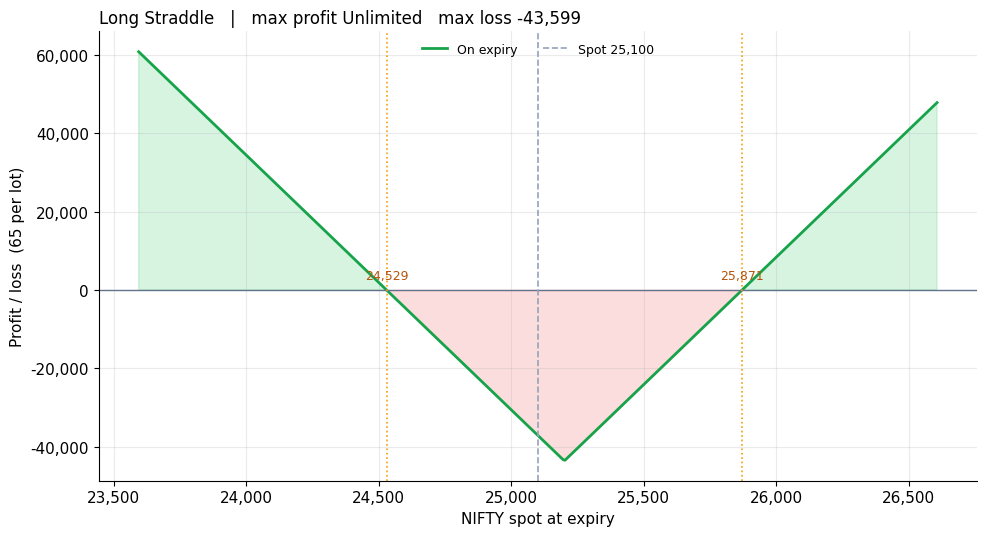

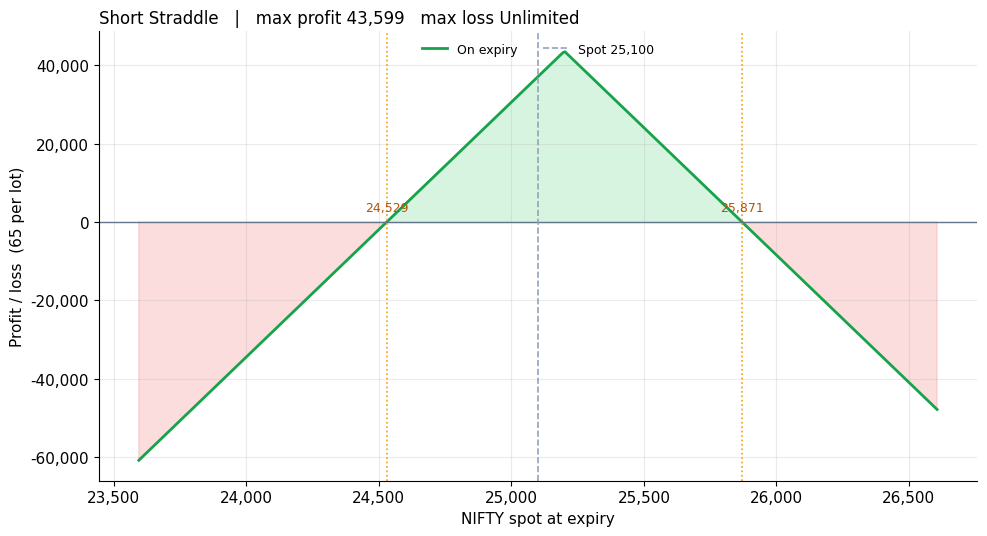

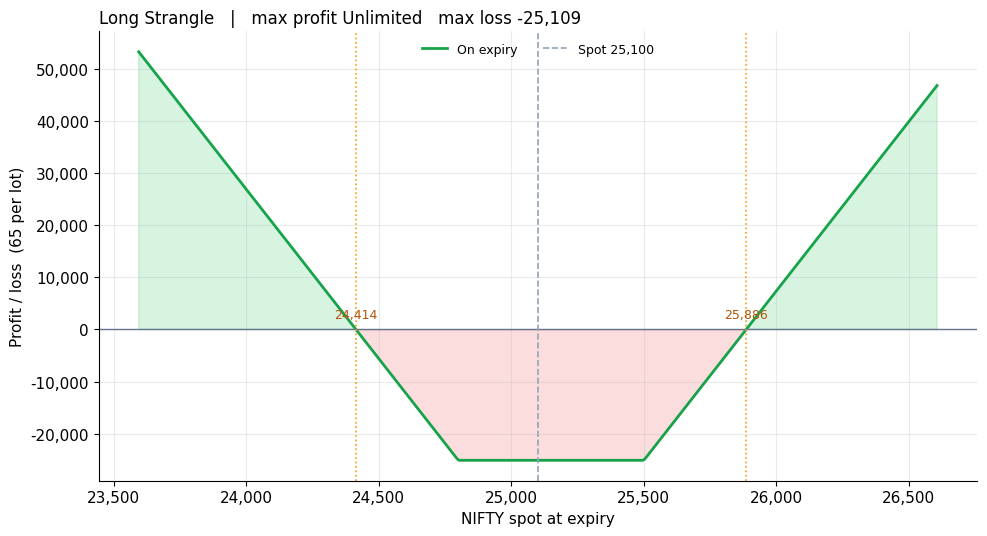

In [12]:
for name in ["Long Straddle", "Short Straddle", "Long Strangle"]:
    plot_strategy(name, STRATEGIES[name])
    plt.tight_layout()
    plt.show()

### Iron condor and iron fly

The first **defined-risk** structures here. Everything above has at least one open tail - a short
straddle loses without limit. Buying a further-out option beyond each short leg caps both ends:

- **Iron fly** - a short straddle with wings. Sell the ATM call and put, buy 300 points either side.
- **Iron condor** - a short strangle with wings. Sell 300 points out, buy 600 points out.

Neither needs new code, which is the point section 4 was making. `payoff_at_expiry` and
`strategy_metrics` take an arbitrary list of legs, so a four-legged structure is four `Leg`s.

One mechanical consequence: a defined-risk structure has `left_slope == 0` **and**
`right_slope == 0`. Both tails are flat, so `strategy_metrics` returns a finite max profit *and* a
finite max loss for the first time in this notebook.

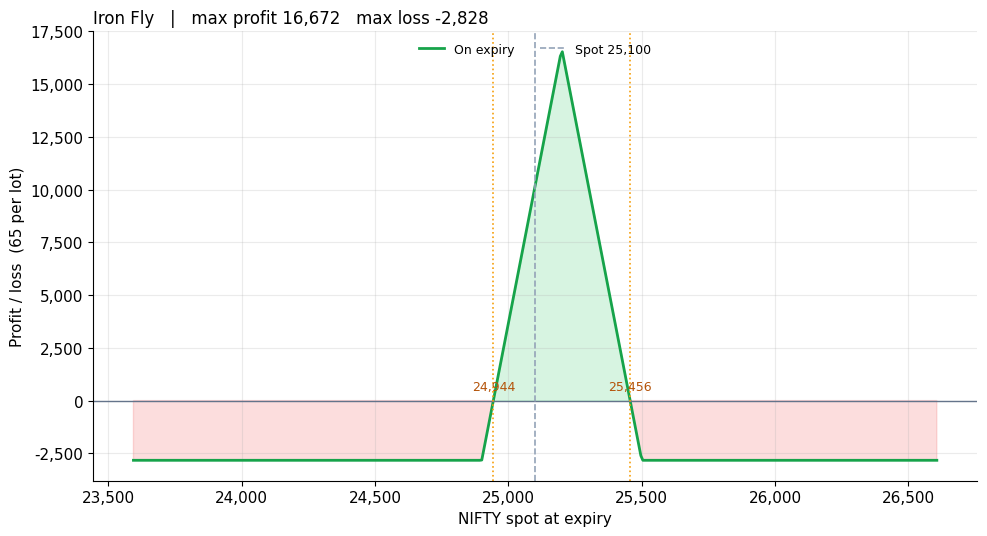

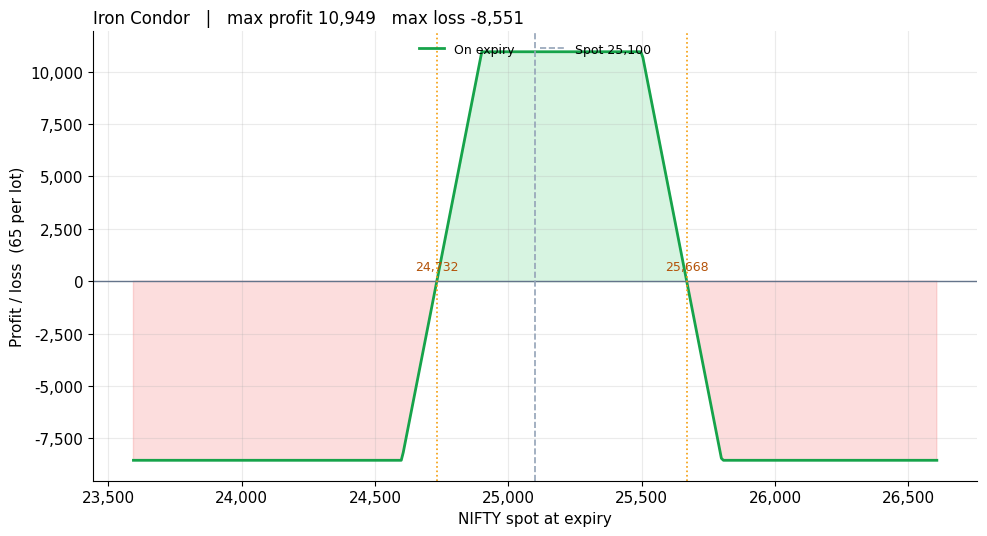

In [13]:
for name in ["Iron Fly", "Iron Condor"]:
    plot_strategy(name, STRATEGIES[name])
    plt.tight_layout()
    plt.show()

#### Check the caps against the arithmetic

The chart looking right is not evidence. For a credit structure with symmetric wings both caps are
forced by arithmetic, so they can be checked without trusting `strategy_metrics` at all:

$$
\text{max profit} = \text{net credit}
\qquad
\text{max loss} = \text{net credit} - (\text{wing width} \times \text{lot})
$$

The wing width is the distance from a short strike to the long strike beyond it. The assertions
below fail the notebook - and so the `execute` CI job - if the two ever disagree.

In [14]:
for name, put_width, call_width in [
    ("Iron Fly",    ATM - FLY_PUT,        FLY_CALL - ATM),
    ("Iron Condor", FLY_PUT - CONDOR_PUT, CONDOR_CALL - FLY_CALL),
]:
    m = strategy_metrics(STRATEGIES[name], LOT_SIZE)
    assert put_width == call_width, f"{name}: wings {put_width:.0f} / {call_width:.0f} are not symmetric"

    credit = -m["net_premium"]                      # net_premium is negative when we are paid
    risk = call_width * LOT_SIZE
    expected_loss = credit - risk

    assert m["left_slope"] == 0 and m["right_slope"] == 0, f"{name} has an open tail"
    assert abs(m["max_profit"] - credit) < 1e-6, f"{name}: max profit != credit"
    assert abs(m["max_loss"] - expected_loss) < 1e-6, f"{name}: max loss != credit - wing x lot"

    print(f"{name}")
    print(f"  wing width   {call_width:,.0f} points x {LOT_SIZE} = {risk:,.2f}")
    print(f"  net credit   {credit:,.2f}")
    print(f"  max profit   {m['max_profit']:,.2f}   = credit")
    print(f"  max loss     {m['max_loss']:,.2f}   = credit - wing x lot")
    print(f"  breakevens   {m['breakevens']}")
    print(f"  risk/reward  1 : {credit / -m['max_loss']:.2f}")

Iron Fly
  wing width   300 points x 65 = 19,500.00
  net credit   16,672.50
  max profit   16,672.50   = credit
  max loss     -2,827.50   = credit - wing x lot
  breakevens   [24943.5, 25456.5]
  risk/reward  1 : 5.90
Iron Condor
  wing width   300 points x 65 = 19,500.00
  net credit   10,949.25
  max profit   10,949.25   = credit
  max loss     -8,550.75   = credit - wing x lot
  breakevens   [24731.55, 25668.45]
  risk/reward  1 : 1.28


### Naked buy and sell

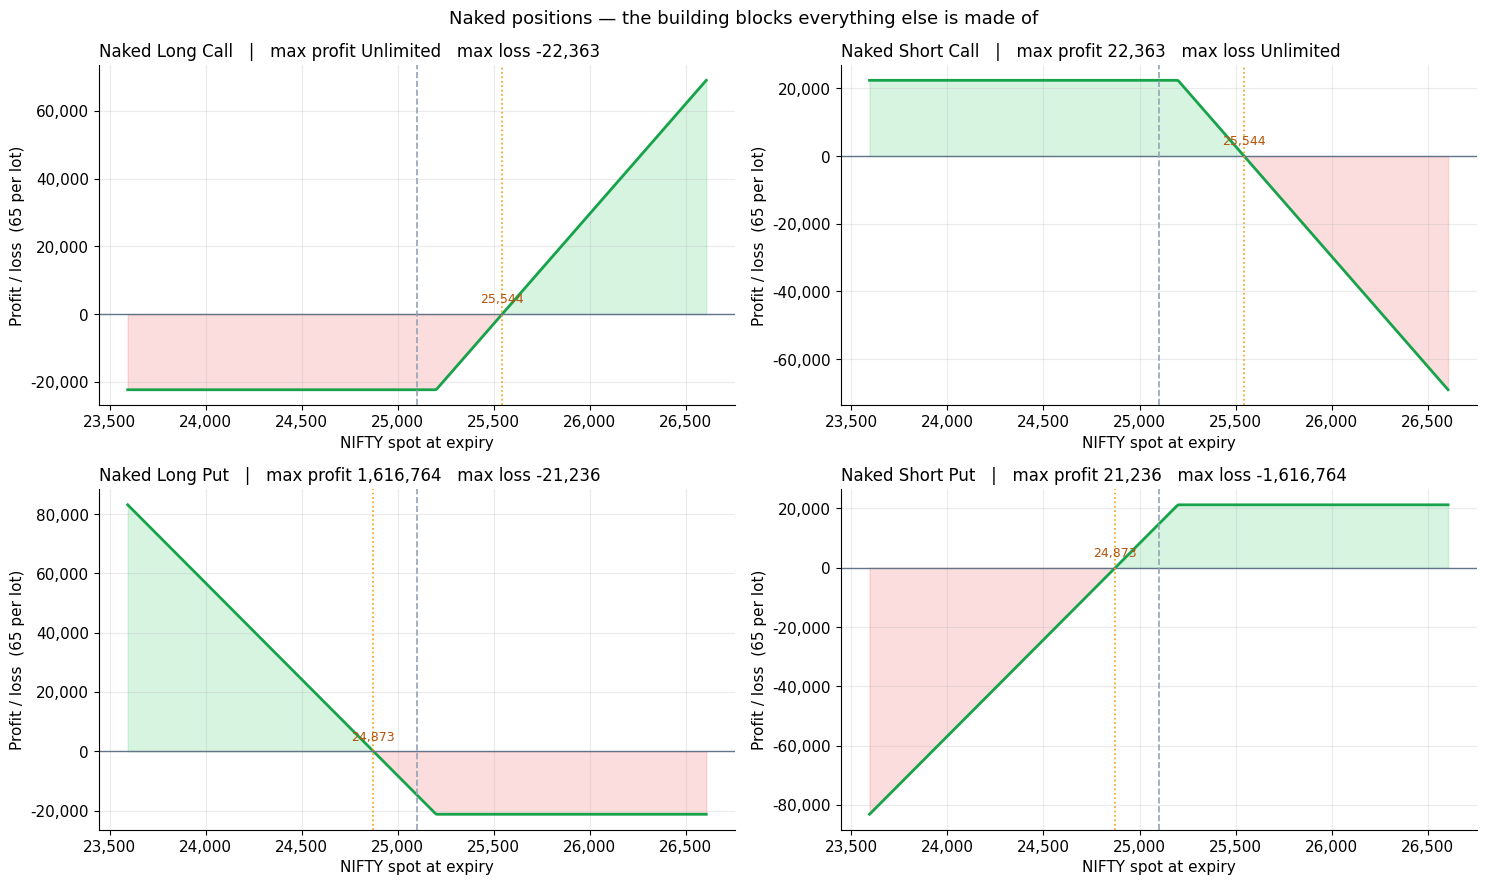

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, name in zip(axes.flat, ["Naked Long Call", "Naked Short Call",
                                "Naked Long Put", "Naked Short Put"]):
    plot_strategy(name, STRATEGIES[name], ax=ax)
    ax.legend().remove()
fig.suptitle("Naked positions — the building blocks everything else is made of", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Summary table

In [16]:
rows = []
for name, legs in STRATEGIES.items():
    m = strategy_metrics(legs, LOT_SIZE)
    rows.append({
        "Strategy": name,
        "Legs": ", ".join(repr(l) for l in legs),
        "Max Profit": fmt(m["max_profit"]),
        "Max Loss": fmt(m["max_loss"]),
        "Breakeven(s)": ", ".join(f"{b:,.0f}" for b in m["breakevens"]) or "-",
        "Net Premium": f"{abs(m['net_premium']):,.0f} {'Dr' if m['net_premium'] > 0 else 'Cr'}",
    })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
summary

,Strategy,Legs,Max Profit,Max Loss,Breakeven(s),Net Premium
0,Long Straddle,"B 1x 25200 CE @ 344.05, B 1x 25200 PE @ 326.70",Unlimited,"-43,599","24,529, 25,871","43,599 Dr"
1,Short Straddle,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70","43,599",Unlimited,"24,529, 25,871","43,599 Cr"
2,Long Strangle,"B 1x 25500 CE @ 206.20, B 1x 24800 PE @ 180.10",Unlimited,"-25,109","24,414, 25,886","25,109 Dr"
3,Iron Fly,"S 1x 25200 CE @ 344.05, S 1x 25200 PE @ 326.70, B 1x 255...","16,672","-2,828","24,944, 25,456","16,672 Cr"
4,Iron Condor,"S 1x 25500 CE @ 206.20, S 1x 24900 PE @ 208.05, B 1x 258...","10,949","-8,551","24,732, 25,668","10,949 Cr"
5,Naked Long Call,B 1x 25200 CE @ 344.05,Unlimited,"-22,363","25,544","22,363 Dr"
6,Naked Short Call,S 1x 25200 CE @ 344.05,"22,363",Unlimited,"25,544","22,363 Cr"
7,Naked Long Put,B 1x 25200 PE @ 326.70,"1,616,764","-21,236","24,873","21,236 Dr"
8,Naked Short Put,S 1x 25200 PE @ 326.70,"21,236","-1,616,764","24,873","21,236 Cr"


### Position Greeks

In [17]:
greek_rows = []
for name, legs in STRATEGIES.items():
    totals = {"delta": 0.0, "gamma": 0.0, "vega": 0.0, "theta": 0.0}
    for leg in legs:
        g = black76_greeks(FORWARD, leg.strike, T, leg.iv, DISCOUNT, leg.is_call)
        for k in totals:
            totals[k] += leg.direction * leg.quantity * g[k]
    greek_rows.append({"Strategy": name, **{k.title(): round(v, 4) for k, v in totals.items()}})

pd.DataFrame(greek_rows)

,Strategy,Delta,Gamma,Vega,Theta
0,Long Straddle,0.0314,0.0009,40.8907,-32.2121
1,Short Straddle,-0.0314,-0.0009,-40.8907,32.2121
2,Long Strangle,0.0618,0.0009,37.5349,-29.7686
3,Iron Fly,-0.0085,-0.0001,-2.4807,1.9998
4,Iron Condor,-0.0178,-0.0002,-6.3385,4.6882
5,Naked Long Call,0.5157,0.0005,20.4453,-16.1002
6,Naked Short Call,-0.5157,-0.0005,-20.4453,16.1002
7,Naked Long Put,-0.4843,0.0005,20.4453,-16.1119
8,Naked Short Put,0.4843,-0.0005,-20.4453,16.1119


## 10. What is still open

Deliberately not decided here, so nothing below is silently assumed:

| Question | Issue |
|---|---|
| Spot-to-forward conversion — we used constant ratio; two other rules are defensible | [#13](https://github.com/lalitkarthik/convex-hedge-payoff/issues/13) |
| Whether implied volatility stays frozen as we roll to the target date | [#8](https://github.com/lalitkarthik/convex-hedge-payoff/issues/8) |
| Margin and funds required, and whether lot size ever changes mid-project | [#4](https://github.com/lalitkarthik/convex-hedge-payoff/issues/4) |
| Probability of profit — expected to be closed-form, not Monte Carlo | [#5](https://github.com/lalitkarthik/convex-hedge-payoff/issues/5) |

**On adding the remaining strategies**: iron condor, iron fly and credit spread need no new code. They
are entries in `STRATEGIES` with four legs and two legs respectively. That falls out of treating a
strategy as a list of legs rather than a type — worth arguing about properly in
[#10](https://github.com/lalitkarthik/convex-hedge-payoff/issues/10), because it decides how many
implementation tickets exist.